# Loading the raw data
- Uses spatialdata package because the data is a .zarr (spatialobject)
- This means it contains several layers:
    - Points (trancripts)
    - Images
    - Tables (AnnData)
    - Shapes (Cells, ROIs etc.)
    - Segmentation (Cell segmentation mask)


In [1]:
%%capture 
import spatialdata as sd
sdata = sd.read_zarr("../data/raw/Varsha_1234.zarr") #lazy loads the data
# print(type(sdata))
# print(sdata)

In [2]:
total = 0
for name, pts in sdata.points.items(): #SpatialData stores points in a container with values saved as a Dask DF of transcript coordinates
    total+= len(pts)                   #The .items() just unpacks item-value pairs from the dict

print("Total points:", total)

# Total points: 2660908 (all 4 stitched slides 1-4 have 2660908 points total)
# Same total as the inital Varsha 1234 zarr file)
# Important sanity check to know that no information was lost in hte zarr conversion 

for name, pts in sdata.points.items():
    print(name, len(pts))

Total points: 2660908
11_points 62260
16_points 70039
13_points 7878
12_points 39823
10_points 68646
17_points 39320
1_points 27425
19_points 20768
18_points 51705
15_points 51745
26_points 65491
23_points 23877
24_points 53603
21_points 58363
22_points 31844
25_points 43413
28_points 56074
20_points 65765
27_points 13845
32_points 30953
29_points 22293
31_points 65206
2_points 64875
30_points 78575
35_points 15792
38_points 35525
33_points 38196
36_points 16265
37_points 29632
3_points 72701
39_points 40745
41_points 63071
43_points 79378
44_points 56336
42_points 49699
48_points 58506
40_points 19318
45_points 65952
47_points 43079
49_points 38690
46_points 62614
50_points 59409
4_points 67413
54_points 12707
53_points 47403
57_points 16168
58_points 2835
52_points 20745
51_points 42487
60_points 6482
5_points 63870
59_points 19393
61_points 15098
64_points 39812
66_points 11427
62_points 20470
65_points 21087
63_points 26036
67_points 32921
9_points 69751
6_points 54138
7_points 436

### The data broadly
- 63 FOVs numbered non-consecutively 
    Initally 67 but 14, 34, 55, 56 are missing (probably empty)
- Each FOV has its own coordinate system
    Points are in local FOV space, not global space
- "Delayed" means the transcript data is just lazy-loaded (would be huge)
- AnnData:
    4325 cells (ish)
    1207 genes (more accurate)
- Each "points" dataframe has 10 columns
- Each FOV has 20,000-80,000 reads
- 2.7 million total reads


In [3]:
# Loading in one FOV to inspect it more closely
fov1 = sdata.points["1_points"].compute() #This .compute() is necessary to convert the lazy Dask DF into a Pandas DF
print(fov1.shape)
print(fov1.columns)
print(fov1.head())
print(fov1.tail())

(27425, 10)
Index(['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov',
       'y_global_px', 'CellComp'],
      dtype='object')
      x     y  target cell_ID  z_raw     cell  x_global_px  fov  y_global_px  \
0  4244   908    IL32       0      7  c_1_1_0        17780    1        46132   
1  4242  1200    LAG3       0      7  c_1_1_0        17778    1        45840   
2  4239  1728     RB1       0      5  c_1_1_0        17775    1        45312   
3  4241  1941  ADGRG3       0      7  c_1_1_0        17777    1        45099   
4  4242  2444  IGFBP6       0      7  c_1_1_0        17778    1        44596   

  CellComp  
0     <NA>  
1     <NA>  
2     <NA>  
3     <NA>  
4     <NA>  
         x     y  target cell_ID  z_raw      cell  x_global_px  fov  \
27420  719  4242   KRT17      89      4  c_1_1_89        14255    1   
27421  718  4237  B3GNT7      89      6  c_1_1_89        14254    1   
27422  717  4234  MALAT1      89      6  c_1_1_89        14253    1   
27423  715 

## More in depth data analysis
10 Columns:
- x, y | FOV-local coordiantes in PIXELS
- x_global_px, y_global_px | Global stitched coordinates in pixels
- target | Gene name
- cell_ID | Assigned cell (0 means it is unassigned)
- z_raw | Z-slice (can be ignored for 2D analysis)
- CellComp | Subcellular compartment (Cytoplasm, nucleus etc.)
- FOV | Which fov that read came from

**I will use global x and y for all of the analysis as the local ones are irrelevant outside of looking at a single FOV**

In [4]:
# Check coordinate ranges
print("Global x range:", fov1['x_global_px'].min(), "to", fov1['x_global_px'].max())
print("Global y range:", fov1['y_global_px'].min(), "to", fov1['y_global_px'].max())

# Check CellComp breakdown
print("\nCellComp value counts:")
print(fov1['CellComp'].value_counts(dropna=False))

# Check cell_ID=0 (unassigned transcripts)
print("\nUnassigned transcripts (cell_ID=0):", (fov1['cell_ID'] == 0).sum())
print("Assigned transcripts:", (fov1['cell_ID'] != 0).sum())

Global x range: 13548 to 17780
Global y range: 42795 to 47024

CellComp value counts:
CellComp
<NA>         11686
Cytoplasm     8962
Nuclear       6764
Membrane        13
Name: count, dtype: int64[pyarrow]

Unassigned transcripts (cell_ID=0): 11756
Assigned transcripts: 15669


### Cell-mapping
- We can see here that the CosMx cell mapping hasn't been successful
- The majority assignment is NA meaning transcripts that lie outside of any known cell
- **This further motivates the segmentation-free approach**

In [5]:
# Gene counts
print("Unique genes:", fov1['target'].nunique())
print("\nTop 20 most abundant genes:")
print(fov1['target'].value_counts().head(20)) #.value_counts() is pandas logic for getting frequency of unique values in a column

Unique genes: 1078

Top 20 most abundant genes:
target
MALAT1    2361
NEAT1      869
PPIA       354
RPL21      345
HMGN2      192
MHC I      177
TPT1       156
ANXA2      141
CSTB       141
KRT18      134
RPL32      131
KRT19      119
S100A2     117
MT2A       113
RPL34      112
SLPI       109
S100A6     106
KRT8       106
IGFBP3     103
KRT17       98
Name: count, dtype: int64


## Gene content
- MALAT1 is a housekeeping gene that is pretty spatially ubiquitous and so it being #1 is reassuring
- I will exclude it from pairwise co-expression tests because its presence is fairly meaningless in this context
    The same goes for NEAT1, PPIA, RPL21

- KRT17, 18 and 19 are all epithelial markers
- S100A2/A6 is epithelia/inflammatory
- SLPI is airway epithelial/anti-inflammatory
    (All biologically meaningful in an infected lung)

In [6]:
total = 0
biggest = ["", 0]

for name, pts in sdata.points.items():
    n = pts.shape[0].compute()
    total += n
    if n > biggest[1]:
        biggest = [name.split('_')[0], n]

print("Biggest FOV:", biggest[0], "with", biggest[1], "points")
print("Total points:", total)

Biggest FOV: 43 with 79378 points
Total points: 2660908


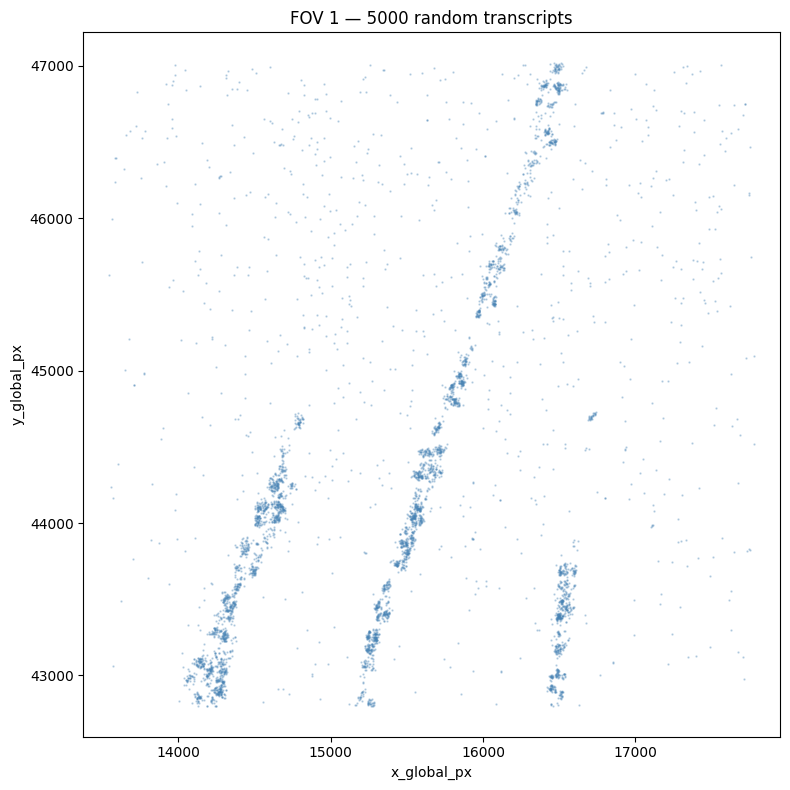

In [7]:
# Quick visual — subsample and plot
import matplotlib.pyplot as plt

sample = fov1.sample(5000, random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(sample['x_global_px'], sample['y_global_px'], 
            s=0.5, alpha=0.3, c='steelblue')
plt.title('FOV 1 — 5000 random transcripts') #just 5000 random points to get a quick visual of the distribution of points 
plt.xlabel('x_global_px')
plt.ylabel('y_global_px')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Data Context
- The 63 (originally 67) FOVs include 4 separate slides
- Each slide has 3 tissue samples in it, in the order of control/infected/control (probably)
- S1 is the most dense and William confirmed it is the best candiate
- S2 is very sparse
- S3 moderately dense but is patchier than S1
- S4 is sparse, with few decent clusters

**I will focus on S1 FOVs for the remainder of the analysis**


In [8]:
%%capture
sdata_s1 = sd.read_zarr("../data/raw/updated_stitched_S1.zarr")
#print(sdata_s1)


## S1 Summary:
- One big stitched image (51,296 x 10,016 pixels)
- 710,751 totals reads

In [9]:
s1_pts = sdata_s1.points['points'].compute() # lazy Dask to eager Pandas DF
print(s1_pts.shape)
print(s1_pts.columns.tolist())
print(s1_pts['fov'].value_counts().sort_index())

(710751, 12)
['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed']
fov
1     27425
2     64875
3     72701
4     67413
5     63870
6     54138
7     43673
8     68298
9     69751
10    68646
11    62260
12    39823
13     7878
Name: count, dtype: int64


- Two new columns now with the transformed coordinates

**Could pull the global coordiantes here to find the FOVs in the large Varsha_1234 file if I wanted**

In [10]:
# Find strip groupings by x position
strip_info = s1_pts.groupby('fov').agg(         # Panda logic for apply aggregate functions 
    n=('target', 'count'),                      # Create an output column 'n' that applies the count function to the target column
    x_mid=('x_global_px_transformed', 'mean'),  # 'source column', 'function'
    y_min=('y_global_px_transformed', 'min'),
    y_max=('y_global_px_transformed', 'max'),
).sort_values('x_mid')

print(strip_info.round(0).to_string()) # to_string forces full printing with no truncation

         n   x_mid    y_min    y_max
fov                                 
11   62260  1990.0   4267.0   8500.0
12   39823  2201.0     12.0   4244.0
10   68646  2211.0   8539.0  12772.0
9    69751  2474.0  12795.0  17027.0
8    68298  2915.0  17099.0  21333.0
13    7878  3268.0  42747.0  46979.0
7    43673  3678.0  21371.0  25604.0
6    54138  4072.0  25643.0  29876.0
5    63870  4356.0  29899.0  34132.0
4    67413  4917.0  34171.0  38404.0
3    72701  5430.0  38475.0  42707.0
2    64875  6446.0  42763.0  46994.0
1    27425  7663.0  47051.0  51280.0


- 13 looks to be a spatial + value outlier

C:\Users\Harry\AppData\Local\Temp\ipykernel_18768\2857601383.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = s1_pts.groupby('fov').apply( # Again groupby() is a pandas function for splitting a DF into groups


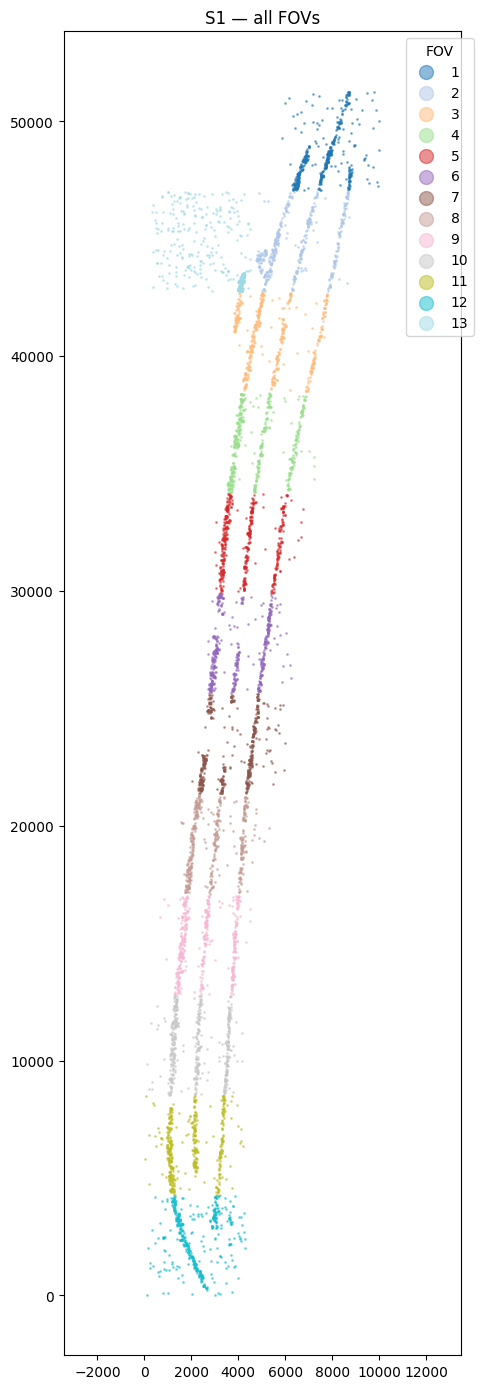

In [11]:
# Visualise all of S1 coloured by FOV
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

sample = s1_pts.groupby('fov').apply( # Again groupby() is a pandas function for splitting a DF into groups
    lambda x: x.sample(min(500, len(x)), random_state=42) # Lambda is python's "anonymous function" syntax for defining a quick function without formally naming it
).reset_index(drop=True) # don't keep the old index as a column

fovs = sample['fov'].unique()
colours = cm.tab20(np.linspace(0, 1, len(fovs))) #cm.tab20 is a matplotlib colour map
colour_map = dict(zip(sorted(fovs), colours))     # pairs each FOV with a colour
                                                  # e.g .(1, (r,g,b,a))
fig, ax = plt.subplots(figsize=(5, 14))
for fov_id, group in sample.groupby('fov'):
    ax.scatter(group['x_global_px_transformed'], 
               group['y_global_px_transformed'],
               s=1, alpha=0.5, color=colour_map[fov_id], label=str(fov_id))
            # s = point size  
ax.legend(markerscale=10, title='FOV', bbox_to_anchor=(1.05, 1))
        #markscale makes the legend points bigger
ax.set_title('S1 — all FOVs')
ax.axis('equal') # forces equal scaling of X and Y so no distortion
plt.tight_layout()
plt.show()

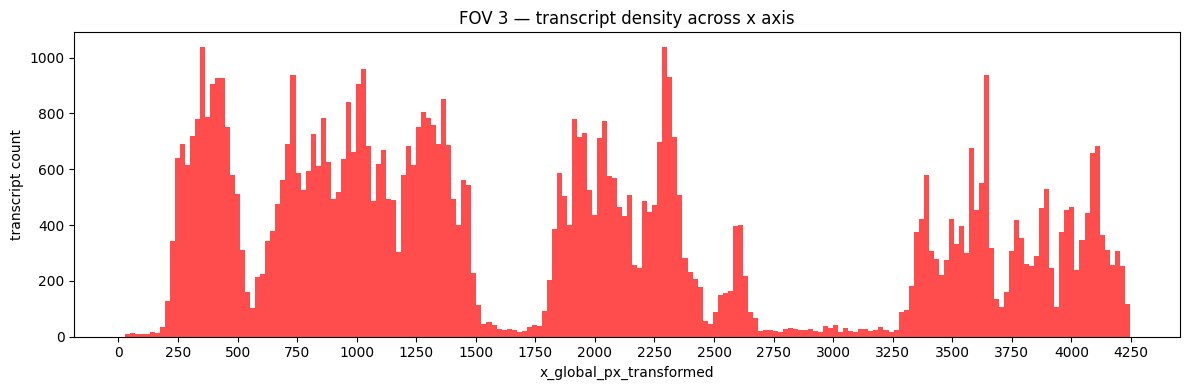

In [12]:
# Look at x distribution within FOV 3
working_fov = s1_pts[s1_pts['fov'] == 3].copy() # extracting just fov 3

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(working_fov['x'], bins=200, color='red', alpha=0.7)
ax.set_xlabel('x_global_px_transformed')
ax.set_ylabel('transcript count')
ax.set_title('FOV 3 — transcript density across x axis')
plt.xticks(np.arange(0, 4500, 250))
plt.tight_layout()
plt.show()

### Histogram analysis
- 3(ish) obvious peaks seen to represent the 3 X-distributed tissues
- The first peak account for the 4th cluster that will be treated as part of strip 1 for now
- Visual extraction of boundaries taken here 

In [13]:
# # Define strip boundaries from visual inspection of histogram
# strip_bounds = {
#     'strip_1': (200, 1550),
#     'strip_2': (1750, 2700),
#     'strip_3': (3250, 4250),
# }

from sklearn.mixture import GaussianMixture

# X-coordinates are multi-modal so 3 clusters of strips
# GMM assumes the data was generated by a mixture of K Gaussian distributions, each with its own mean and variance
gmm = GaussianMixture(n_components=3, random_state=42).fit(working_fov[['x']])
# This says "find the 3 gausssians that best fit the x distribution"
# Returns the centre and spread of each distribution automatically

# GMM doesn't guarantee components are ordered left-to-right
# so we sort component indices by their mean x position
order = np.argsort(gmm.means_.flatten())
# order is e.g. [2, 0, 1] meaning component 2 is leftmost strip

# Predict posterior probabilities for each transcript
# probs shape: (n_transcripts, 3)
# probs[i, k] = P(component k | x_i)
probs = gmm.predict_proba(working_fov[['x']])
probs_ordered = probs[:, order]

# Assign each transcript to the strip with highest posterior
# This is the Bayes-optimal assignment
strip_idx = np.argmax(probs_ordered, axis=1)  # 0, 1, or 2

# Map to named labels
strip_labels = {0: 'strip_1', 1: 'strip_2', 2: 'strip_3'}
working_fov['strip'] = [strip_labels[i] for i in strip_idx]

# Inspect the fitted parameters
for rank, comp_idx in enumerate(order):
    mu = gmm.means_[comp_idx, 0]
    sigma = np.sqrt(gmm.covariances_[comp_idx, 0, 0])
    weight = gmm.weights_[comp_idx]
    print(f"strip_{rank+1}: mean x={mu:.0f}, σ={sigma:.0f}, weight={weight:.3f}")

# Optional: flag low-confidence assignments
confidence = probs_ordered.max(axis=1)
working_fov['strip_confidence'] = confidence
working_fov['strip_ambiguous'] = confidence < 0.8  # tunable threshold

# # Assign strips
# def assign_strip(x):
#     for strip, (lo, hi) in strip_bounds.items():
#         if lo <= x <= hi:
#             return strip
#     return None

# working_fov['strip'] = working_fov['x'].apply(assign_strip)

# Check counts per strip
print(working_fov['strip'].value_counts())
print(f"Unassigned (in gaps): {working_fov['strip'].isna().sum()}")

strip_1: mean x=871, σ=396, weight=0.526
strip_2: mean x=2169, σ=239, weight=0.246
strip_3: mean x=3751, σ=286, weight=0.227
strip
strip_1    37870
strip_2    18283
strip_3    16548
Name: count, dtype: int64
Unassigned (in gaps): 0


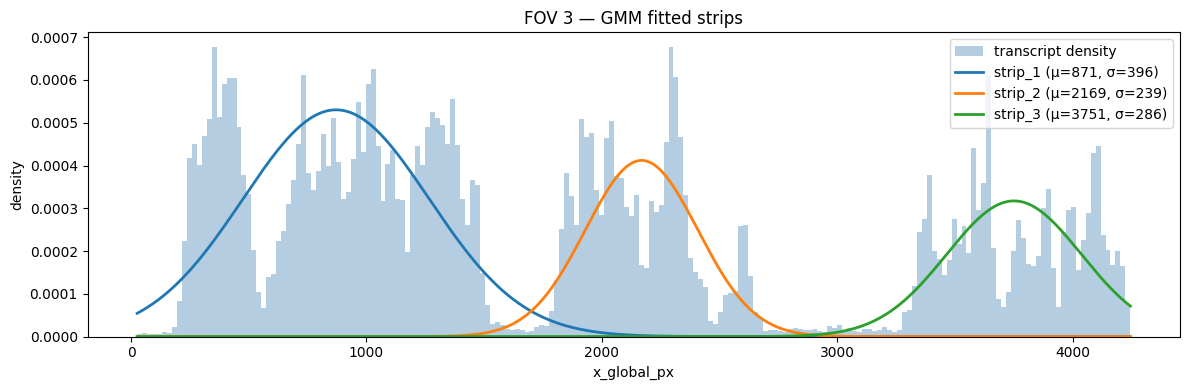

In [14]:
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(12, 4))

# Plot the histogram of x coordinates (density=True so it's on same scale as Gaussians)
ax.hist(working_fov['x'], bins=200, density=True, alpha=0.4, color='steelblue', label='transcript density')

# Plot each fitted Gaussian
x_range = np.linspace(working_fov['x'].min(), working_fov['x'].max(), 1000)

for rank, comp_idx in enumerate(order):
    mu = gmm.means_[comp_idx, 0]
    sigma = np.sqrt(gmm.covariances_[comp_idx, 0, 0])
    weight = gmm.weights_[comp_idx]
    
    # Weight scales the Gaussian to reflect how many transcripts belong to it
    y = weight * norm.pdf(x_range, mu, sigma)
    ax.plot(x_range, y, label=f'strip_{rank+1} (μ={mu:.0f}, σ={sigma:.0f})', linewidth=2)

ax.set_xlabel('x_global_px')
ax.set_ylabel('density')
ax.set_title('FOV 3 — GMM fitted strips')
ax.legend()
plt.tight_layout()
plt.show()

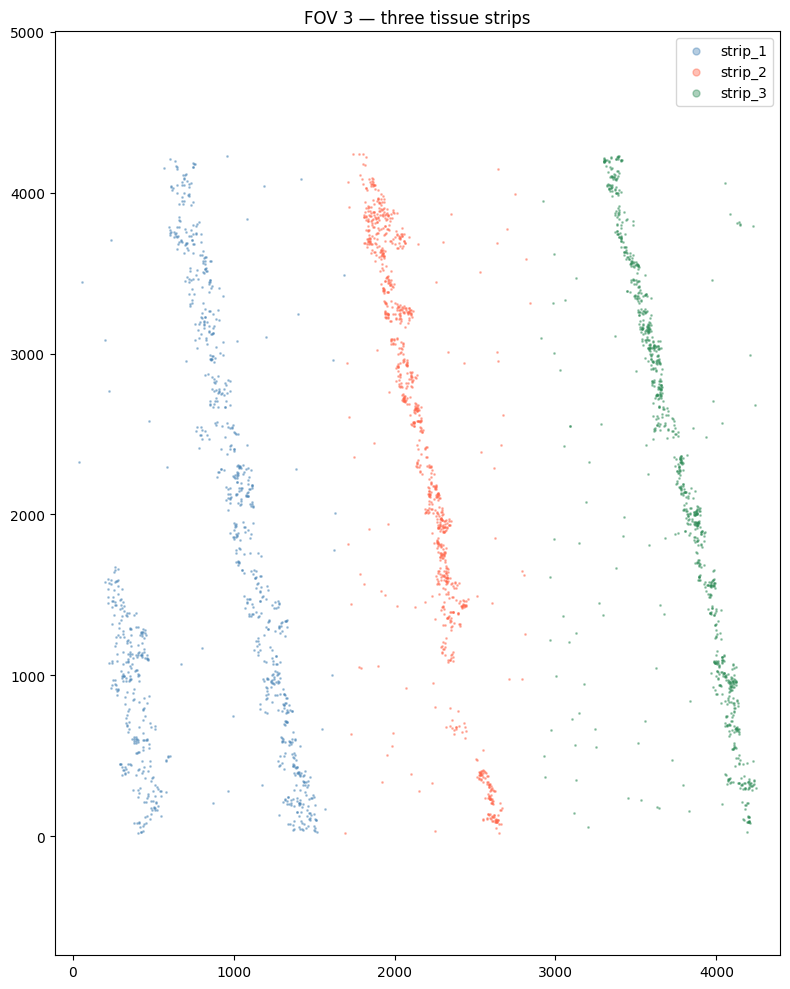

In [15]:
# Visualise the three strips
fig, ax = plt.subplots(figsize=(8, 10))

colors = {'strip_1': 'steelblue', 'strip_2': 'tomato', 'strip_3': 'seagreen'}
for strip, color in colors.items():
    sub = working_fov[working_fov['strip'] == strip].sample(1000, random_state=42)
    ax.scatter(sub['x'], sub['y'], s=1, alpha=0.4, color=color, label=strip)

ax.legend(markerscale=5)
ax.set_title('FOV 3 — three tissue strips')
ax.axis('equal')
plt.tight_layout()
plt.show()

In [16]:
working_fov.attrs = {}  #DF has affine transformation metadata attached so just have to remove those before saving
working_fov.to_parquet("../data/processed/fov3_strips.parquet") 